# Minimal Character GPT on CPU

This executed notebook records the implementation checks, baseline run, controlled experiments, sampling study, and a no-repeat 3-gram extension. The model lives in `min_llm.py`; measured outputs and analysis are retained here as reproducibility evidence.


# 1 实验准备

本实验训练一个字符级 MiniGPT。模型接收一段诗句的前文，同时预测每个位置的下一个字符。虽然模型只有约 50 万参数，但它保留了 GPT 的核心组成：token 嵌入、位置嵌入、多头因果自注意力、Pre-Norm Transformer 块、MLP、残差连接以及自回归采样。

本实验以字符级下一字符预测为训练目标，在 CPU 上实现并训练一个小型 GPT。实验首先完成字符编码、上下文与标签构造、因果自注意力和 Transformer 块的实现，再通过基线训练观察 loss 变化和自回归生成结果。随后分别改变学习率、层数、嵌入维度、上下文长度和位置编码，在其他条件相同的情况下比较训练效果。最后固定同一基线模型，分析 temperature 和 top-k 对生成确定性、多样性与重复现象的影响。

In [1]:
from pathlib import Path
import json
import math
import os
import platform
import subprocess
import sys

from IPython.display import Image, Markdown, display


def locate_experiment_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "labs" / "03-min-llm",
    ]
    for candidate in candidates:
        if (candidate / "min_llm.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("未找到 min_llm.py，请从 labs/03-min-llm 或仓库根目录运行 Notebook。")


BASE_DIR = locate_experiment_dir()
SCRIPT = BASE_DIR / "min_llm.py"
RESULTS_DIR = BASE_DIR / "results"
LOGS_DIR = RESULTS_DIR / "logs"
RESULTS_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)

print("实验目录：", BASE_DIR)
print("实验脚本：", SCRIPT)

实验目录： .
实验脚本： .\min_llm.py


## 1.1 实验环境

In [2]:
print("操作系统：", platform.platform())
print("Python：", sys.version.replace("\n", " "))
print("Python 可执行文件：", sys.executable)
print("CPU：", platform.processor() or "请从系统信息中补充")
print("逻辑 CPU 数：", os.cpu_count())

try:
    import torch
    print("PyTorch：", torch.__version__)
    print("PyTorch 线程数：", torch.get_num_threads())
except ImportError as exc:
    print("PyTorch 未安装：", exc)

try:
    import matplotlib
    print("matplotlib：", matplotlib.__version__)
except ImportError as exc:
    print("matplotlib 未安装：", exc)

操作系统： Windows-11-10.0.26200-SP0
Python： 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
Python 可执行文件： python
CPU： Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
逻辑 CPU 数： 24
PyTorch： 2.6.0+cu124
PyTorch 线程数： 16
matplotlib： 3.10.1


实验在 Windows 11 上完成，使用 Python 3.13.3、PyTorch 2.6.0+cu124 和 matplotlib 3.10.1。模型仅在 CPU 上训练，PyTorch 使用 16 个线程。所有正式实验固定随机种子为 42，并在同一台计算机上串行运行，以减少系统负载差异对耗时比较的影响。虽然安装的 PyTorch 包包含 CUDA 标识，本实验程序明确将设备设为 `cpu`，没有使用 GPU。

# 2 阅读 `min_llm.py`

正式运行前，我先按实验流程的顺序阅读程序。下方函数只显示源码，不会启动训练。

In [3]:
SOURCE_LINES = SCRIPT.read_text(encoding="utf-8").splitlines()


def show_source(start_marker, end_marker=None):
    start = next(i for i, line in enumerate(SOURCE_LINES) if start_marker in line)
    if end_marker is None:
        end = len(SOURCE_LINES)
    else:
        end = next(
            i for i, line in enumerate(SOURCE_LINES[start + 1 :], start + 1)
            if end_marker in line
        )
    numbered = "\n".join(
        f"{i + 1:04d}  {SOURCE_LINES[i]}" for i in range(start, end)
    )
    display(Markdown(f"```python\n{numbered}\n```"))

## 2.1 语料、分词和训练样本

程序使用实验指南给出的唐诗作为内置语料，将语料中每个不同字符作为一个 token。`stoi` 完成字符到整数编号的映射，`itos` 完成反向映射。训练数据从完整 token 序列中随机截取连续片段，输入为前 `T` 个字符，标签为向后错开一位的 `T` 个字符。

例如文本片段是“春眠不觉晓”，当上下文长度为 4 时，输入是“春眠不觉”，标签是“眠不觉晓”。这样一次前向传播就包含了四个下一字符预测任务。

In [4]:
show_source("# ============ 1.", "# ============ 3.")

```python
0027  # ============ 1. 内置语料：实验指南给出的精选诗句 ============
0028  POEMS = [
0029      "床前明月光，疑是地上霜。举头望明月，低头思故乡。",
0030      "春眠不觉晓，处处闻啼鸟。夜来风雨声，花落知多少。",
0031      "白日依山尽，黄河入海流。欲穷千里目，更上一层楼。",
0032      "锄禾日当午，汗滴禾下土。谁知盘中餐，粒粒皆辛苦。",
0033      "离离原上草，一岁一枯荣。野火烧不尽，春风吹又生。",
0034      "远芳侵古道，晴翠接荒城。又送王孙去，萋萋满别情。",
0035      "千山鸟飞绝，万径人踪灭。孤舟蓑笠翁，独钓寒江雪。",
0036      "鹅，鹅，鹅，曲项向天歌。白毛浮绿水，红掌拨清波。",
0037      "两个黄鹂鸣翠柳，一行白鹭上青天。窗含西岭千秋雪，门泊东吴万里船。",
0038      "朝辞白帝彩云间，千里江陵一日还。两岸猿声啼不住，轻舟已过万重山。",
0039      "故人西辞黄鹤楼，烟花三月下扬州。孤帆远影碧空尽，唯见长江天际流。",
0040      "李白乘舟将欲行，忽闻岸上踏歌声。桃花潭水深千尺，不及汪伦送我情。",
0041      "日照香炉生紫烟，遥看瀑布挂前川。飞流直下三千尺，疑是银河落九天。",
0042      "天门中断楚江开，碧水东流至此回。两岸青山相对出，孤帆一片日边来。",
0043      "月落乌啼霜满天，江枫渔火对愁眠。姑苏城外寒山寺，夜半钟声到客船。",
0044      "清明时节雨纷纷，路上行人欲断魂。借问酒家何处有，牧童遥指杏花村。",
0045      "独在异乡为异客，每逢佳节倍思亲。遥知兄弟登高处，遍插茱萸少一人。",
0046      "烟笼寒水月笼沙，夜泊秦淮近酒家。商女不知亡国恨，隔江犹唱后庭花。",
0047      "折戟沉沙铁未销，自将磨洗认前朝。东风不与周郎便，铜雀春深锁二乔。",
0048      "巴山楚水凄凉地，二十三年弃置身。怀旧空吟闻笛赋，到乡翻似烂柯人。",
0049      "沉舟侧畔千帆过，病树前头万木春。今日听君歌一曲，暂凭杯酒长精神。",
0050      "朱雀桥边野草花，乌衣巷口夕阳斜。旧时王谢堂前燕，飞入寻常百姓家。",
0051      "湖光秋月两相和，潭面无风镜未磨。遥望洞庭山水翠，白银盘里一青螺。",
0052      "杨柳青青江水平，闻郎江上踏歌声。东边日出西边雨，道是无晴却有晴。",
0053      "自古逢秋悲寂寥，我言秋日胜春朝。晴空一鹤排云上，便引诗情到碧霄。",
0054      "前不见古人，后不见来者。念天地之悠悠，独怆然而涕下。",
0055      "葡萄美酒夜光杯，欲饮琵琶马上催。醉卧沙场君莫笑，古来征战几人回。",
0056      "黄河远上白云间，一片孤城万仞山。羌笛何须怨杨柳，春风不度玉门关。",
0057      "秦时明月汉时关，万里长征人未还。但使龙城飞将在，不教胡马度阴山。",
0058      "月黑雁飞高，单于夜遁逃。欲将轻骑逐，大雪满弓刀。",
0059      "好雨知时节，当春乃发生。随风潜入夜，润物细无声。",
0060      "晓看红湿处，花重锦官城。野径云俱黑，江船火独明。",
0061      "国破山河在，城春草木深。感时花溅泪，恨别鸟惊心。",
0062      "烽火连三月，家书抵万金。白头搔更短，浑欲不胜簪。",
0063      "细草微风岸，危樯独夜舟。星垂平野阔，月涌大江流。",
0064      "风急天高猿啸哀，渚清沙白鸟飞回。无边落木萧萧下，不尽长江滚滚来。",
0065      "花近高楼伤客心，万方多难此登临。锦江春色来天地，玉垒浮云变古今。",
0066      "独怜幽草涧边生，上有黄鹂深树鸣。春潮带雨晚来急，野渡无人舟自横。",
0067      "天街小雨润如酥，草色遥看近却无。最是一年春好处，绝胜烟柳满皇都。",
0068      "昔人已乘黄鹤去，此地空余黄鹤楼。黄鹤一去不复返，白云千载空悠悠。",
0069      "晴川历历汉阳树，芳草萋萋鹦鹉洲。日暮乡关何处是，烟波江上使人愁。",
0070      "客舍青青柳色新，渭城朝雨浥轻尘。劝君更尽一杯酒，西出阳关无故人。",
0071      "寒雨连江夜入吴，平明送客楚山孤。洛阳亲友如相问，一片冰心在玉壶。",
0072      "山光忽西落，池月渐东上。散发乘夕凉，开轩卧闲敞。",
0073      "荷笠带斜阳，青山独归远。苍苍竹林寺，杳杳钟声晚。",
0074      "空山不见人，但闻人语响。返景入深林，复照青苔上。",
0075      "人闲桂花落，夜静春山空。月出惊山鸟，时鸣春涧中。",
0076      "红豆生南国，春来发几枝。愿君多采撷，此物最相思。",
0077      "独坐幽篁里，弹琴复长啸。深林人不知，明月来相照。",
0078      "君自故乡来，应知故乡事。来日绮窗前，寒梅著花未。",
0079      "山中相送罢，日暮掩柴扉。春草明年绿，王孙归不归。",
0080      "花间一壶酒，独酌无相亲。举杯邀明月，对影成三人。",
0081      "小时不识月，呼作白玉盘。又疑瑶台镜，飞在青云端。",
0082      "长安一片月，万户捣衣声。秋风吹不尽，总是玉关情。",
0083      "弃我去者，昨日之日不可留。乱我心者，今日之日多烦忧。",
0084      "抽刀断水水更流，举杯消愁愁更愁。人生在世不称意，明朝散发弄扁舟。",
0085      "千里黄云白日曛，北风吹雁雪纷纷。莫愁前路无知己，天下谁人不识君。",
0086      "慈母手中线，游子身上衣。临行密密缝，意恐迟迟归。谁言寸草心，报得三春晖。",
0087      "山重水复疑无路，柳暗花明又一村。莫笑农家腊酒浑，丰年留客足鸡豚。",
0088      "纸上得来终觉浅，绝知此事要躬行。古人学问无遗力，少壮功夫老始成。",
0089      "死去元知万事空，但悲不见九州同。王师北定中原日，家祭无忘告乃翁。",
0090      "小荷才露尖尖角，早有蜻蜓立上头。泉眼无声惜细流，树阴照水爱晴柔。",
0091      "接天莲叶无穷碧，映日荷花别样红。毕竟西湖六月中，风光不与四时同。",
0092      "胜日寻芳泗水滨，无边光景一时新。等闲识得东风面，万紫千红总是春。",
0093      "半亩方塘一鉴开，天光云影共徘徊。问渠那得清如许，为有源头活水来。",
0094      "郁孤台下清江水，中间多少行人泪。西北望长安，可怜无数山。",
0095      "人生自古谁无死，留取丹心照汗青。辛苦遭逢起一经，干戈寥落四周星。",
0096      "咬定青山不放松，立根原在破岩中。千磨万击还坚劲，任尔东西南北风。",
0097      "千锤万凿出深山，烈火焚烧若等闲。粉骨碎身浑不怕，要留清白在人间。",
0098      "浩荡离愁白日斜，吟鞭东指即天涯。落红不是无情物，化作春泥更护花。",
0099      "九州生气恃风雷，万马齐喑究可哀。我劝天公重抖擞，不拘一格降人才。",
0100      "力微任重久神疲，再竭衰庸定不支。苟利国家生死以，岂因祸福避趋之。",
0101  ]
0102  
0103  
0104  def build_corpus(extra_file=None):
0105      """拼接内置语料；若指定的补充语料存在，则追加其内容。"""
0106      text = "\n".join(POEMS)
0107      if extra_file:
0108          extra_path = Path(extra_file)
0109          if not extra_path.is_absolute():
0110              extra_path = Path(__file__).resolve().parent / extra_path
0111          if extra_path.exists():
0112              text += "\n" + extra_path.read_text(encoding="utf-8")
0113              print(f"已追加语料：{extra_path}")
0114      return text
0115  
0116  
0117  # ============ 2. 字符级分词器 ============
0118  class CharTokenizer:
0119      def __init__(self, text=None, chars=None):
0120          if chars is None:
0121              if text is None:
0122                  raise ValueError("text 和 chars 至少提供一个")
0123              chars = sorted(set(text))
0124          self.chars = list(chars)
0125          self.stoi = {ch: i for i, ch in enumerate(self.chars)}
0126          self.itos = {i: ch for ch, i in self.stoi.items()}
0127          self.vocab_size = len(self.chars)
0128  
0129      def encode(self, text):
0130          """将字符串编码为 token ID；提示词中的未知字符会被忽略。"""
0131          return [self.stoi[ch] for ch in text if ch in self.stoi]
0132  
0133      def decode(self, ids):
0134          return "".join(self.itos[int(i)] for i in ids)
0135  
0136  
```

## 2.2 因果自注意力和 Transformer

输入张量形状是 `(B,T,C)`。一次线性投影同时得到 Q、K、V，随后拆成 `(B,H,T,C/H)`。注意力分数的形状为 `(B,H,T,T)`，下三角因果掩码把未来位置填成负无穷，使 softmax 后对应概率为 0。各注意力头完成加权求和后重新合并为 `(B,T,C)`。

Transformer 块采用 Pre-Norm：先归一化再进入注意力或 MLP，两个子层外都保留残差连接。最终输出层与 token 嵌入共享权重，因此参数量手算时 `V×C` 只计算一次。

In [5]:
show_source("class CausalSelfAttention", "# ============ 4.")

```python
0138  class CausalSelfAttention(nn.Module):
0139      """带因果掩码的多头自注意力。"""
0140  
0141      def __init__(self, n_embd, n_head, block_size):
0142          super().__init__()
0143          if n_embd % n_head != 0:
0144              raise ValueError("n_embd 必须能被 n_head 整除")
0145          self.n_head = n_head
0146          self.qkv = nn.Linear(n_embd, 3 * n_embd)
0147          self.proj = nn.Linear(n_embd, n_embd)
0148          mask = torch.tril(torch.ones(block_size, block_size))
0149          self.register_buffer("mask", mask.view(1, 1, block_size, block_size))
0150  
0151      def forward(self, x):
0152          batch_size, seq_len, n_embd = x.shape
0153          q, k, v = self.qkv(x).split(n_embd, dim=2)
0154  
0155          # (B, T, C) -> (B, H, T, D)，其中 D=C/H。
0156          q = q.view(batch_size, seq_len, self.n_head, -1).transpose(1, 2)
0157          k = k.view(batch_size, seq_len, self.n_head, -1).transpose(1, 2)
0158          v = v.view(batch_size, seq_len, self.n_head, -1).transpose(1, 2)
0159  
0160          att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
0161          att = att.masked_fill(
0162              self.mask[:, :, :seq_len, :seq_len] == 0, float("-inf")
0163          )
0164          att = F.softmax(att, dim=-1)
0165          y = att @ v
0166  
0167          # (B, H, T, D) -> (B, T, C)。
0168          y = y.transpose(1, 2).contiguous().view(batch_size, seq_len, n_embd)
0169          return self.proj(y)
0170  
0171  
0172  class Block(nn.Module):
0173      """Pre-Norm Transformer 块。"""
0174  
0175      def __init__(self, n_embd, n_head, block_size):
0176          super().__init__()
0177          self.ln1 = nn.LayerNorm(n_embd)
0178          self.attn = CausalSelfAttention(n_embd, n_head, block_size)
0179          self.ln2 = nn.LayerNorm(n_embd)
0180          self.mlp = nn.Sequential(
0181              nn.Linear(n_embd, 4 * n_embd),
0182              nn.GELU(),
0183              nn.Linear(4 * n_embd, n_embd),
0184          )
0185  
0186      def forward(self, x):
0187          x = x + self.attn(self.ln1(x))
0188          x = x + self.mlp(self.ln2(x))
0189          return x
0190  
0191  
0192  class MiniGPT(nn.Module):
0193      def __init__(
0194          self,
0195          vocab_size,
0196          n_embd=128,
0197          n_head=4,
0198          n_layer=2,
0199          block_size=128,
0200          use_pos=True,
0201      ):
0202          super().__init__()
0203          self.block_size = block_size
0204          self.tok_emb = nn.Embedding(vocab_size, n_embd)
0205          self.pos_emb = (
0206              nn.Embedding(block_size, n_embd) if use_pos else None
0207          )
0208          self.blocks = nn.ModuleList(
0209              [Block(n_embd, n_head, block_size) for _ in range(n_layer)]
0210          )
0211          self.ln_f = nn.LayerNorm(n_embd)
0212          self.head = nn.Linear(n_embd, vocab_size, bias=False)
0213  
0214          # 输入词嵌入和输出分类层共享同一份权重。
0215          self.head.weight = self.tok_emb.weight
0216          self.apply(self._init_weights)
0217  
0218      def _init_weights(self, module):
0219          """小方差初始化，使初始预测接近均匀分布。"""
0220          if isinstance(module, nn.Linear):
0221              nn.init.normal_(module.weight, mean=0.0, std=0.02)
0222              if module.bias is not None:
0223                  nn.init.zeros_(module.bias)
0224          elif isinstance(module, nn.Embedding):
0225              nn.init.normal_(module.weight, mean=0.0, std=0.02)
0226  
0227      def forward(self, idx, targets=None):
0228          _, seq_len = idx.shape
0229          if seq_len > self.block_size:
0230              raise ValueError("输入序列长度超过 block_size")
0231  
0232          pos = torch.arange(seq_len, device=idx.device)
0233          x = self.tok_emb(idx)
0234          if self.pos_emb is not None:
0235              x = x + self.pos_emb(pos)
0236  
0237          for block in self.blocks:
0238              x = block(x)
0239  
0240          logits = self.head(self.ln_f(x))
0241          loss = None
0242          if targets is not None:
0243              loss = F.cross_entropy(
0244                  logits.reshape(-1, logits.size(-1)), targets.reshape(-1)
0245              )
0246          return logits, loss
0247  
0248      @staticmethod
0249      def _banned_ngram_tokens(sequence, ngram_size):
0250          """返回会重复已有 n-gram 的候选 token，用于选做实验。"""
0251          if ngram_size <= 0 or len(sequence) < ngram_size - 1:
0252              return set()
0253          prefix = tuple(sequence[-(ngram_size - 1) :]) if ngram_size > 1 else ()
0254          banned = set()
0255          for start in range(len(sequence) - ngram_size + 1):
0256              old_prefix = tuple(sequence[start : start + ngram_size - 1])
0257              if old_prefix == prefix:
0258                  banned.add(sequence[start + ngram_size - 1])
0259          return banned
0260  
0261      @torch.no_grad()
0262      def generate(
0263          self,
0264          idx,
0265          max_new_tokens=200,
0266          temperature=1.0,
0267          top_k=None,
0268          no_repeat_ngram_size=0,
0269      ):
0270          """按 temperature 和 top-k 自回归采样。"""
0271          if temperature <= 0:
0272              raise ValueError("temperature 必须大于 0")
0273          self.eval()
0274  
0275          for _ in range(max_new_tokens):
0276              idx_cond = idx[:, -self.block_size :]
0277              logits, _ = self(idx_cond)
0278              logits = logits[:, -1, :] / temperature
0279  
0280              if no_repeat_ngram_size > 0:
0281                  for row in range(idx.size(0)):
0282                      sequence = idx[row].tolist()
0283                      banned = self._banned_ngram_tokens(
0284                          sequence, no_repeat_ngram_size
0285                      )
0286                      if banned:
0287                          logits[row, list(banned)] = float("-inf")
0288  
0289              if top_k is not None and top_k > 0:
0290                  k = min(top_k, logits.size(-1))
0291                  threshold = torch.topk(logits, k)[0][:, -1:]
0292                  logits = logits.masked_fill(logits < threshold, float("-inf"))
0293  
0294              # 极端限制导致所有候选都被屏蔽时，退回未限制的模型分布。
0295              if not torch.isfinite(logits).any(dim=-1).all():
0296                  fallback, _ = self(idx_cond)
0297                  logits = fallback[:, -1, :] / temperature
0298  
0299              probs = F.softmax(logits, dim=-1)
0300              next_id = torch.multinomial(probs, 1)
0301              idx = torch.cat([idx, next_id], dim=1)
0302          return idx
0303  
0304  
```

## 2.3 训练和采样

训练阶段使用交叉熵衡量每个位置的下一字符预测误差。随机初始化时，各字符的预测概率接近均匀分布，所以初始 loss 理论上接近 `ln(V)`。生成阶段每次只取最后一个位置的 logits，通过 temperature 调整分布尖锐程度，再使用 top-k 限制候选字符，最后按概率采样一个新字符并追加到上下文。

In [6]:
show_source("# ============ 4.")

```python
0305  # ============ 4. 数据批生成 ============
0306  def get_batch(data, block_size, batch_size, device):
0307      """随机截取 block_size+1 个 token，并把标签错开一位。"""
0308      if len(data) <= block_size:
0309          raise ValueError("语料长度必须大于 block_size")
0310      starts = torch.randint(len(data) - block_size, (batch_size,))
0311      x = torch.stack([data[i : i + block_size] for i in starts])
0312      y = torch.stack([data[i + 1 : i + block_size + 1] for i in starts])
0313      return x.to(device), y.to(device)
0314  
0315  
0316  # ============ 5. 训练、保存和采样 ============
0317  def build_parser():
0318      parser = argparse.ArgumentParser(description="CPU 字符级 MiniGPT 实验")
0319      parser.add_argument("--iters", type=int, default=2000)
0320      parser.add_argument("--batch_size", type=int, default=32)
0321      parser.add_argument("--block_size", type=int, default=128)
0322      parser.add_argument("--n_embd", type=int, default=128)
0323      parser.add_argument("--n_head", type=int, default=4)
0324      parser.add_argument("--n_layer", type=int, default=2)
0325      parser.add_argument("--lr", type=float, default=1e-3)
0326      parser.add_argument("--seed", type=int, default=42)
0327      parser.add_argument("--num_threads", type=int, default=0)
0328      parser.add_argument("--temperature", type=float, default=1.0)
0329      parser.add_argument("--top_k", type=int, default=20)
0330      parser.add_argument("--max_new_tokens", type=int, default=200)
0331      parser.add_argument("--prompts", type=str, default="春,月")
0332      parser.add_argument("--samples_per_prompt", type=int, default=2)
0333      parser.add_argument("--no_pos", action="store_true")
0334      parser.add_argument("--extra_corpus", type=str, default="corpus_extra.txt")
0335      parser.add_argument("--output_dir", type=str, default="results")
0336      parser.add_argument("--run_name", type=str, default="")
0337      parser.add_argument("--save_checkpoint", action="store_true")
0338      parser.add_argument("--checkpoint", type=str, default="")
0339      parser.add_argument("--sample_only", action="store_true")
0340      parser.add_argument("--skip_generation", action="store_true")
0341      parser.add_argument("--no_repeat_ngram_size", type=int, default=0)
0342      return parser
0343  
0344  
0345  def make_run_tag(args):
0346      if args.run_name:
0347          return args.run_name
0348      if args.no_pos:
0349          return "no_pos"
0350      block_part = "" if args.block_size == 128 else f"_T{args.block_size}"
0351      return f"L{args.n_layer}_E{args.n_embd}{block_part}_lr{args.lr:g}"
0352  
0353  
0354  def model_config_from_args(args, vocab_size):
0355      return {
0356          "vocab_size": vocab_size,
0357          "n_embd": args.n_embd,
0358          "n_head": args.n_head,
0359          "n_layer": args.n_layer,
0360          "block_size": args.block_size,
0361          "use_pos": not args.no_pos,
0362      }
0363  
0364  
0365  def save_checkpoint(path, model, tokenizer, model_config, run_tag):
0366      payload = {
0367          "model_state_dict": model.state_dict(),
0368          "chars": tokenizer.chars,
0369          "model_config": model_config,
0370          "run_tag": run_tag,
0371      }
0372      torch.save(payload, path)
0373  
0374  
0375  def load_checkpoint(path, device):
0376      try:
0377          payload = torch.load(path, map_location=device, weights_only=False)
0378      except TypeError:
0379          payload = torch.load(path, map_location=device)
0380      tokenizer = CharTokenizer(chars=payload["chars"])
0381      config = payload["model_config"]
0382      model = MiniGPT(**config).to(device)
0383      model.load_state_dict(payload["model_state_dict"])
0384      return model, tokenizer, config, payload.get("run_tag", "checkpoint")
0385  
0386  
0387  def save_losses_csv(path, losses):
0388      with path.open("w", encoding="utf-8-sig", newline="") as file:
0389          writer = csv.writer(file)
0390          writer.writerow(["iteration", "loss"])
0391          writer.writerows(enumerate(losses, start=1))
0392  
0393  
0394  def save_loss_curve(path, losses, args):
0395      import matplotlib
0396  
0397      matplotlib.use("Agg")
0398      import matplotlib.pyplot as plt
0399  
0400      plt.figure(figsize=(7, 4))
0401      plt.plot(losses, linewidth=0.8)
0402      plt.xlabel("Iteration")
0403      plt.ylabel("Cross-Entropy Loss")
0404      plt.title(
0405          "Training Loss "
0406          f"(L={args.n_layer}, E={args.n_embd}, T={args.block_size}, "
0407          f"lr={args.lr:g}, pos={'off' if args.no_pos else 'on'})"
0408      )
0409      plt.tight_layout()
0410      plt.savefig(path, dpi=150)
0411      plt.close()
0412  
0413  
0414  def generate_samples(model, tokenizer, args, model_tag, output_dir, device):
0415      prompts = [item.strip() for item in args.prompts.split(",") if item.strip()]
0416      records = []
0417      sections = []
0418  
0419      for prompt_index, prompt in enumerate(prompts):
0420          encoded = tokenizer.encode(prompt)
0421          if not encoded:
0422              raise ValueError(f"提示词不含词表内字符：{prompt!r}")
0423          for sample_index in range(args.samples_per_prompt):
0424              sample_seed = args.seed + 1000 + prompt_index * 100 + sample_index
0425              torch.manual_seed(sample_seed)
0426              start = torch.tensor([encoded], dtype=torch.long, device=device)
0427              output = model.generate(
0428                  start,
0429                  max_new_tokens=args.max_new_tokens,
0430                  temperature=args.temperature,
0431                  top_k=args.top_k,
0432                  no_repeat_ngram_size=args.no_repeat_ngram_size,
0433              )
0434              text = tokenizer.decode(output[0].tolist())
0435              records.append(
0436                  {
0437                      "prompt": prompt,
0438                      "sample_index": sample_index + 1,
0439                      "sample_seed": sample_seed,
0440                      "text": text,
0441                  }
0442              )
0443              sections.append(
0444                  f"提示词：{prompt}｜样本：{sample_index + 1}｜seed：{sample_seed}\n{text}"
0445              )
0446  
0447      top_k_text = "all" if args.top_k <= 0 else str(args.top_k)
0448      sample_tag = (
0449          f"{model_tag}_temp{args.temperature:g}_topk{top_k_text}"
0450          f"_ngram{args.no_repeat_ngram_size}"
0451      )
0452      text_path = output_dir / f"generated_{sample_tag}.txt"
0453      text_path.write_text("\n\n".join(sections) + "\n", encoding="utf-8")
0454  
0455      # 与结果文件兼容的基线文件名。
0456      if (
0457          model_tag == "L2_E128_lr0.001"
0458          and args.temperature == 1.0
0459          and args.top_k == 20
0460          and args.no_repeat_ngram_size == 0
0461      ):
0462          (output_dir / "generated_base.txt").write_text(
0463              "\n\n".join(sections) + "\n", encoding="utf-8"
0464          )
0465  
0466      print(f"已保存生成文本：{text_path}")
0467      return records, text_path
0468  
0469  
0470  def main():
0471      args = build_parser().parse_args()
0472      if args.iters <= 0 and not args.sample_only:
0473          raise ValueError("iters 必须大于 0")
0474      if args.samples_per_prompt <= 0:
0475          raise ValueError("samples_per_prompt 必须大于 0")
0476      if args.num_threads > 0:
0477          torch.set_num_threads(args.num_threads)
0478  
0479      random.seed(args.seed)
0480      torch.manual_seed(args.seed)
0481      device = "cpu"
0482  
0483      script_dir = Path(__file__).resolve().parent
0484      output_dir = Path(args.output_dir)
0485      if not output_dir.is_absolute():
0486          output_dir = script_dir / output_dir
0487      output_dir.mkdir(parents=True, exist_ok=True)
0488  
0489      print(
0490          f"PyTorch {torch.__version__} | 设备：{device} | "
0491          f"线程数：{torch.get_num_threads()}"
0492      )
0493  
0494      if args.sample_only:
0495          if not args.checkpoint:
0496              raise ValueError("--sample_only 必须同时提供 --checkpoint")
0497          checkpoint_path = Path(args.checkpoint)
0498          if not checkpoint_path.is_absolute():
0499              checkpoint_path = script_dir / checkpoint_path
0500          model, tokenizer, model_config, model_tag = load_checkpoint(
0501              checkpoint_path, device
0502          )
0503          n_params = sum(parameter.numel() for parameter in model.parameters())
0504          print(f"已加载检查点：{checkpoint_path}")
0505          print(f"模型参数量：{n_params:,} | 配置：{model_config}")
0506          records, text_path = generate_samples(
0507              model, tokenizer, args, model_tag, output_dir, device
0508          )
0509          summary = {
0510              "mode": "sample_only",
0511              "checkpoint": str(checkpoint_path),
0512              "model_tag": model_tag,
0513              "model_config": model_config,
0514              "n_params": n_params,
0515              "temperature": args.temperature,
0516              "top_k": args.top_k,
0517              "no_repeat_ngram_size": args.no_repeat_ngram_size,
0518              "generated_file": str(text_path),
0519              "samples": records,
0520          }
0521          summary_tag = (
0522              f"sample_{model_tag}_temp{args.temperature:g}_"
0523              f"topk{args.top_k}_ngram{args.no_repeat_ngram_size}"
0524          )
0525          summary_path = output_dir / f"summary_{summary_tag}.json"
0526          summary_path.write_text(
0527              json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
0528          )
0529          print(f"已保存摘要：{summary_path}")
0530          return
0531  
0532      text = build_corpus(args.extra_corpus)
0533      tokenizer = CharTokenizer(text=text)
0534      data = torch.tensor(tokenizer.encode(text), dtype=torch.long)
0535      print(f"语料：{len(text)} 字符 | 词表大小 V = {tokenizer.vocab_size}")
0536  
0537      model_config = model_config_from_args(args, tokenizer.vocab_size)
0538      model = MiniGPT(**model_config).to(device)
0539      n_params = sum(parameter.numel() for parameter in model.parameters())
0540      run_tag = make_run_tag(args)
0541      print(
0542          f"模型参数量：{n_params:,} ({n_params / 1e6:.2f}M) | "
0543          f"配置：L={args.n_layer} H={args.n_head} E={args.n_embd} "
0544          f"T={args.block_size} pos={'有' if not args.no_pos else '无'}"
0545      )
0546  
0547      optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr)
0548      losses = []
0549      start_time = time.time()
0550  
0551      model.train()
0552      for step in range(1, args.iters + 1):
0553          xb, yb = get_batch(data, args.block_size, args.batch_size, device)
0554          _, loss = model(xb, yb)
0555          optimizer.zero_grad(set_to_none=True)
0556          loss.backward()
0557          optimizer.step()
0558          losses.append(loss.item())
0559  
0560          if step == 1 or step % 100 == 0 or step == args.iters:
0561              elapsed = time.time() - start_time
0562              speed = step / max(elapsed, 1e-8)
0563              eta = (args.iters - step) / max(speed, 1e-8)
0564              print(
0565                  f"step {step:5d}/{args.iters} | loss {loss.item():.4f} | "
0566                  f"{speed:.2f} it/s | 预计剩余 {eta:.0f}s"
0567              )
0568  
0569      train_time = time.time() - start_time
0570      first_window = losses[: min(100, len(losses))]
0571      print(
0572          f"训练完成，耗时 {train_time / 60:.2f} 分钟 | "
0573          f"初始 loss {losses[0]:.4f} | 最终 loss {losses[-1]:.4f} | "
0574          f"前 {len(first_window)} 步均值 {sum(first_window) / len(first_window):.4f}"
0575      )
0576  
0577      losses_path = output_dir / f"losses_{run_tag}.csv"
0578      curve_path = output_dir / f"loss_curve_{run_tag}.png"
0579      save_losses_csv(losses_path, losses)
0580      save_loss_curve(curve_path, losses, args)
0581      print(f"已保存 loss 数据：{losses_path}")
0582      print(f"已保存 loss 曲线：{curve_path}")
0583  
0584      checkpoint_path = None
0585      if args.save_checkpoint:
0586          checkpoint_path = output_dir / f"checkpoint_{run_tag}.pt"
0587          save_checkpoint(
0588              checkpoint_path, model, tokenizer, model_config, run_tag
0589          )
0590          print(f"已保存检查点：{checkpoint_path}")
0591  
0592      samples = []
0593      generated_path = None
0594      if not args.skip_generation:
0595          samples, generated_path = generate_samples(
0596              model, tokenizer, args, run_tag, output_dir, device
0597          )
0598  
0599      summary = {
0600          "mode": "train",
0601          "run_tag": run_tag,
0602          "seed": args.seed,
0603          "torch_version": torch.__version__,
0604          "num_threads": torch.get_num_threads(),
0605          "corpus_chars": len(text),
0606          "vocab_size": tokenizer.vocab_size,
0607          "model_config": model_config,
0608          "batch_size": args.batch_size,
0609          "iters": args.iters,
0610          "lr": args.lr,
0611          "n_params": n_params,
0612          "initial_loss": losses[0],
0613          "final_loss": losses[-1],
0614          "train_seconds": train_time,
0615          "losses_file": str(losses_path),
0616          "curve_file": str(curve_path),
0617          "checkpoint_file": str(checkpoint_path) if checkpoint_path else None,
0618          "generated_file": str(generated_path) if generated_path else None,
0619          "samples": samples,
0620      }
0621      summary_path = output_dir / f"summary_{run_tag}.json"
0622      summary_path.write_text(
0623          json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
0624      )
0625      print(f"已保存实验摘要：{summary_path}")
0626  
0627  
0628  if __name__ == "__main__":
0629      main()
```

### 代码阅读记录

阅读注意力实现时，我重点核对了多头拆分前后的形状。Q、K、V 从 `(B,T,C)` 变为 `(B,H,T,C/H)`，计算得到的注意力矩阵为 `(B,H,T,T)`。因果掩码只保留下三角区域，确保位置 `t` 无法访问 `t` 之后的标签。合并多头前先把张量转回 `(B,T,H,C/H)`，再连续存储并 reshape 为 `(B,T,C)`。

我还检查了 `self.head.weight = self.tok_emb.weight`，确认输出层与词嵌入引用同一个参数。批数据函数把连续的 `block_size+1` 个 token 拆成错开一位的输入和标签。训练循环按照清梯度、反向传播和参数更新的顺序执行；生成阶段只取最后一个位置的 logits，再应用 temperature、top-k 和可选的 n-gram 限制。

# 3 运行与结果保存

In [8]:
def run_experiment(log_name, *arguments):
    command = [sys.executable, str(SCRIPT), *map(str, arguments)]
    print("运行命令：")
    print(" ".join(command))
    completed = subprocess.run(
        command,
        cwd=BASE_DIR,
        text=True,
        encoding="utf-8",
        errors="replace",
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print(completed.stdout)
    log_path = LOGS_DIR / f"{log_name}.txt"
    log_path.write_text(
        "命令：\n" + " ".join(command) + "\n\n输出：\n" + completed.stdout,
        encoding="utf-8",
    )
    print("日志：", log_path)
    if completed.returncode != 0:
        raise RuntimeError(f"实验失败，退出码 {completed.returncode}，请先分析日志。")
    return completed.stdout


def load_summary(filename, folder=RESULTS_DIR):
    path = folder / filename
    if not path.exists():
        raise FileNotFoundError(f"尚未生成：{path}")
    return json.loads(path.read_text(encoding="utf-8"))


def show_image(filename, folder=RESULTS_DIR):
    path = folder / filename
    if not path.exists():
        raise FileNotFoundError(f"尚未生成：{path}")
    display(Image(filename=str(path)))

## 3.1 少量迭代检查

先运行 5 步，只检查数据、前向传播、反向传播、绘图和文件保存能否完成。这次输出不作为报告结果。

In [9]:
run_experiment(
    "smoke_5_steps",
    "--iters", 5,
    "--batch_size", 2,
    "--max_new_tokens", 10,
    "--samples_per_prompt", 1,
    "--run_name", "smoke_5_steps",
    "--output_dir", "results/smoke",
)

运行命令：
python .\min_llm.py --iters 5 --batch_size 2 --max_new_tokens 10 --samples_per_prompt 1 --run_name smoke_5_steps --output_dir results/smoke
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有
step     1/5 | loss 6.5418 | 9.78 it/s | 预计剩余 0s
step     5/5 | loss 6.1751 | 29.61 it/s | 预计剩余 0s
训练完成，耗时 0.00 分钟 | 初始 loss 6.5418 | 最终 loss 6.1751 | 前 5 步均值 6.3482
已保存 loss 数据：.\results\smoke\losses_smoke_5_steps.csv
已保存 loss 曲线：.\results\smoke\loss_curve_smoke_5_steps.png
已保存生成文本：.\results\smoke\generated_smoke_5_steps_temp1_topk20_ngram0.txt
已保存实验摘要：.\results\smoke\summary_smoke_5_steps.json

日志： .\results\logs\smoke_5_steps.txt


'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有\nstep     1/5 | loss 6.5418 | 9.78 it/s | 预计剩余 0s\nstep     5/5 | loss 6.1751 | 29.61 it/s | 预计剩余 0s\n训练完成，耗时 0.00 分钟 | 初始 loss 6.5418 | 最终 loss 6.1751 | 前 5 步均值 6.3482\n已保存 loss 数据：.\\results\\smoke\\losses_smoke_5_steps.csv\n已保存 loss 曲线：.\\results\\smoke\\loss_curve_smoke_5_steps.png\n已保存生成文本：.\\results\\smoke\\generated_smoke_5_steps_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\smoke\\summary_smoke_5_steps.json\n'

### 快速检查记录

5 步检查成功完成。语料词表大小为 699，模型参数量为 502,656；loss 从 6.5418 变为 6.1751，运行耗时约 0.17 秒。程序在 `results/smoke` 中生成了 loss CSV、曲线、生成文本和 JSON 摘要，说明数据构造、前向传播、反向传播、绘图和结果保存流程可以正常工作。该次运行步数太少，只用于检查程序，不用于评价收敛和生成质量。

# 4 基线实验

基线使用 2 层 Transformer、128 维嵌入、4 个注意力头、128 字符上下文、batch size 32、学习率 `1e-3` 和 2000 个训练步骤。该次运行额外保存模型检查点，后续采样实验都加载这一检查点。

In [10]:
run_experiment(
    "baseline_2000",
    "--iters", 2000,
    "--save_checkpoint",
    "--prompts", "春,月",
    "--samples_per_prompt", 2,
)

运行命令：
python .\min_llm.py --iters 2000 --save_checkpoint --prompts 春,月 --samples_per_prompt 2
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有
step     1/2000 | loss 6.5619 | 8.25 it/s | 预计剩余 242s
step   100/2000 | loss 1.5036 | 18.63 it/s | 预计剩余 102s
step   200/2000 | loss 0.1416 | 19.15 it/s | 预计剩余 94s
step   300/2000 | loss 0.0771 | 19.27 it/s | 预计剩余 88s
step   400/2000 | loss 0.0507 | 19.33 it/s | 预计剩余 83s
step   500/2000 | loss 0.0430 | 19.40 it/s | 预计剩余 77s
step   600/2000 | loss 0.0391 | 19.46 it/s | 预计剩余 72s
step   700/2000 | loss 0.0320 | 19.50 it/s | 预计剩余 67s
step   800/2000 | loss 0.0342 | 19.54 it/s | 预计剩余 61s
step   900/2000 | loss 0.0306 | 19.52 it/s | 预计剩余 56s
step  1000/2000 | loss 0.0232 | 19.55 it/s | 预计剩余 51s
step  1100/2000 | loss 0.0261 | 19.56 it/s | 预计剩余 46s
step  1200/2000 | loss 0.0339 | 19.57 it/s | 预计剩余 41s
step  1300/2000 | loss 0.0235 | 19.59 it/s | 预计剩余 36s
step  1400/2000 | loss 0.0261 | 

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有\nstep     1/2000 | loss 6.5619 | 8.25 it/s | 预计剩余 242s\nstep   100/2000 | loss 1.5036 | 18.63 it/s | 预计剩余 102s\nstep   200/2000 | loss 0.1416 | 19.15 it/s | 预计剩余 94s\nstep   300/2000 | loss 0.0771 | 19.27 it/s | 预计剩余 88s\nstep   400/2000 | loss 0.0507 | 19.33 it/s | 预计剩余 83s\nstep   500/2000 | loss 0.0430 | 19.40 it/s | 预计剩余 77s\nstep   600/2000 | loss 0.0391 | 19.46 it/s | 预计剩余 72s\nstep   700/2000 | loss 0.0320 | 19.50 it/s | 预计剩余 67s\nstep   800/2000 | loss 0.0342 | 19.54 it/s | 预计剩余 61s\nstep   900/2000 | loss 0.0306 | 19.52 it/s | 预计剩余 56s\nstep  1000/2000 | loss 0.0232 | 19.55 it/s | 预计剩余 51s\nstep  1100/2000 | loss 0.0261 | 19.56 it/s | 预计剩余 46s\nstep  1200/2000 | loss 0.0339 | 19.57 it/s | 预计剩余 41s\nstep  1300/2000 | loss 0.0235 | 19.59 it/s | 预计剩余 36s\nstep  1400/2000 | loss 0.0261 | 19.60 it/s | 预计剩余 31s\nstep  1500/2000 | loss 0.0238 | 19.51 it/s | 预计剩余 26s

词表大小： 699
参数量： 502656
初始 loss： 6.561903953552246
理论 ln(V)： 6.54965074223381
最终 loss： 0.02578936517238617
训练耗时/分钟： 1.72663494348526
生成文本： .\results\generated_L2_E128_lr0.001_temp1_topk20_ngram0.txt


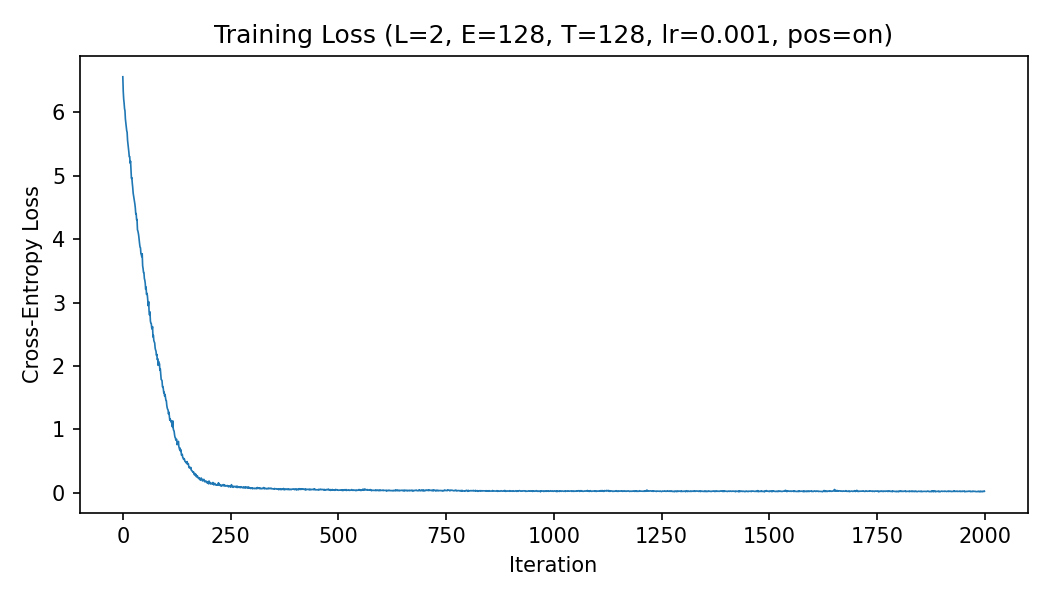

In [11]:
baseline = load_summary("summary_L2_E128_lr0.001.json")
print("词表大小：", baseline["vocab_size"])
print("参数量：", baseline["n_params"])
print("初始 loss：", baseline["initial_loss"])
print("理论 ln(V)：", math.log(baseline["vocab_size"]))
print("最终 loss：", baseline["final_loss"])
print("训练耗时/分钟：", baseline["train_seconds"] / 60)
print("生成文本：", baseline["generated_file"])
show_image("loss_curve_L2_E128_lr0.001.png")

## 4.1 基线结果

基线模型词表大小为 699，共有 502,656 个参数。理论均匀预测交叉熵为 `ln(699)=6.5497`，实测第一步 loss 为 6.5619，两者相差约 0.0122，说明初始化后的输出接近均匀分布。训练 2000 步后，最后一步 loss 为 0.0258，最后 100 步平均 loss 为 0.0230，最低记录值为 0.0158。总训练时间为 1.73 分钟，平均速度约 19.31 it/s。

曲线在前 200 步快速下降到 0.1416，约 400 步后降到 0.05 左右，后续在较低水平小幅波动。2000 步的最后一次随机 batch loss 略高于 1000 步时的 0.0232，因此单独比较最后一步并不稳定；最后 100 步均值更能反映整体收敛水平。

以“春”为提示词时，模型生成了“春深锁二乔。巴山楚水凄凉地，二十三年弃置身……”；以“月”为提示词时，生成了“月来相照。君自故乡来，应知故乡事……”。句式和标点较完整，但后续内容大段逐字出现在训练语料中，最长连续匹配达到 201 个字符。这说明模型在小语料上主要形成了记忆和续接，而不是获得通用的诗歌创作能力。

![基线训练 loss 曲线](results/loss_curve_L2_E128_lr0.001.png)

# 5 参数量手算

In [12]:
V = baseline["vocab_size"]
C, T, L = 128, 128, 2

token_embedding = V * C
position_embedding = T * C
transformer_blocks = L * 12 * C**2
approx_total = token_embedding + position_embedding + transformer_blocks
exact_total = baseline["n_params"]
relative_error = abs(exact_total - approx_total) / exact_total

print(f"词嵌入：{V} × {C} = {token_embedding:,}")
print(f"位置嵌入：{T} × {C} = {position_embedding:,}")
print(f"Transformer：{L} × 12 × {C}² = {transformer_blocks:,}")
print(f"近似总参数：{approx_total:,}")
print(f"代码精确参数：{exact_total:,}")
print(f"相对误差：{relative_error:.4%}")

词嵌入：699 × 128 = 89,472
位置嵌入：128 × 128 = 16,384
Transformer：2 × 12 × 128² = 393,216
近似总参数：499,072
代码精确参数：502,656
相对误差：0.7130%


## 5.1 手算验证

基线词表大小为 699，嵌入维度为 128，因此词嵌入参数量为 `699×128=89,472`。输出层与词嵌入共享权重，所以不再重复计算输出矩阵。位置嵌入参数量为 `128×128=16,384`。每层注意力包含 Q、K、V 和输出投影，约为 `4C²`；MLP 的两次线性变换约为 `8C²`，所以两层 Transformer 约有 `2×12×128²=393,216` 个参数。

三项相加得到：

\[
89,472+16,384+393,216=499,072
\]

代码打印的精确参数量为 502,656，差异为 3,584，来自线性层偏置和 LayerNorm 等小参数。相对误差为 `3,584/502,656≈0.71%`，小于 1%，手算结果与代码一致。

# 6 对照实验

正式基线按要求训练 2000 步。为了让对照实验严格只改变目标变量，我另外运行一个 1000 步共同参照组；exp1～exp5 也统一训练 1000 步。所有运行固定语料、batch size 和随机种子，并在同一台 CPU 上串行执行。

## 6.1 共同参照与学习率

In [13]:
run_experiment("control_1000", "--iters", 1000, "--run_name", "control_1000")

运行命令：
python .\min_llm.py --iters 1000 --run_name control_1000
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有
step     1/1000 | loss 6.5619 | 9.77 it/s | 预计剩余 102s
step   100/1000 | loss 1.5036 | 19.51 it/s | 预计剩余 46s
step   200/1000 | loss 0.1416 | 19.59 it/s | 预计剩余 41s
step   300/1000 | loss 0.0771 | 19.66 it/s | 预计剩余 36s
step   400/1000 | loss 0.0507 | 19.65 it/s | 预计剩余 31s
step   500/1000 | loss 0.0430 | 19.59 it/s | 预计剩余 26s
step   600/1000 | loss 0.0391 | 19.52 it/s | 预计剩余 20s
step   700/1000 | loss 0.0320 | 19.48 it/s | 预计剩余 15s
step   800/1000 | loss 0.0342 | 19.40 it/s | 预计剩余 10s
step   900/1000 | loss 0.0306 | 19.38 it/s | 预计剩余 5s
step  1000/1000 | loss 0.0232 | 19.37 it/s | 预计剩余 0s
训练完成，耗时 0.86 分钟 | 初始 loss 6.5619 | 最终 loss 0.0232 | 前 100 步均值 3.5881
已保存 loss 数据：.\results\losses_control_1000.csv
已保存 loss 曲线：.\results\loss_curve_control_1000.png
已保存生成文本：.\results\generated_control_1000_temp1_topk20_ngram0.tx

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有\nstep     1/1000 | loss 6.5619 | 9.77 it/s | 预计剩余 102s\nstep   100/1000 | loss 1.5036 | 19.51 it/s | 预计剩余 46s\nstep   200/1000 | loss 0.1416 | 19.59 it/s | 预计剩余 41s\nstep   300/1000 | loss 0.0771 | 19.66 it/s | 预计剩余 36s\nstep   400/1000 | loss 0.0507 | 19.65 it/s | 预计剩余 31s\nstep   500/1000 | loss 0.0430 | 19.59 it/s | 预计剩余 26s\nstep   600/1000 | loss 0.0391 | 19.52 it/s | 预计剩余 20s\nstep   700/1000 | loss 0.0320 | 19.48 it/s | 预计剩余 15s\nstep   800/1000 | loss 0.0342 | 19.40 it/s | 预计剩余 10s\nstep   900/1000 | loss 0.0306 | 19.38 it/s | 预计剩余 5s\nstep  1000/1000 | loss 0.0232 | 19.37 it/s | 预计剩余 0s\n训练完成，耗时 0.86 分钟 | 初始 loss 6.5619 | 最终 loss 0.0232 | 前 100 步均值 3.5881\n已保存 loss 数据：.\\results\\losses_control_1000.csv\n已保存 loss 曲线：.\\results\\loss_curve_control_1000.png\n已保存生成文本：.\\results\\generated_control_1000_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summary_control_

In [14]:
run_experiment("exp1_lr_0.01", "--iters", 1000, "--lr", 0.01)

运行命令：
python .\min_llm.py --iters 1000 --lr 0.01
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有
step     1/1000 | loss 6.5619 | 9.60 it/s | 预计剩余 104s
step   100/1000 | loss 4.1494 | 12.92 it/s | 预计剩余 70s
step   200/1000 | loss 1.8081 | 11.57 it/s | 预计剩余 69s
step   300/1000 | loss 0.5293 | 11.06 it/s | 预计剩余 63s
step   400/1000 | loss 0.1718 | 10.85 it/s | 预计剩余 55s
step   500/1000 | loss 0.1059 | 10.86 it/s | 预计剩余 46s
step   600/1000 | loss 0.0957 | 10.92 it/s | 预计剩余 37s
step   700/1000 | loss 0.0607 | 10.92 it/s | 预计剩余 27s
step   800/1000 | loss 0.0597 | 10.99 it/s | 预计剩余 18s
step   900/1000 | loss 0.0541 | 11.07 it/s | 预计剩余 9s
step  1000/1000 | loss 0.0413 | 11.17 it/s | 预计剩余 0s
训练完成，耗时 1.49 分钟 | 初始 loss 6.5619 | 最终 loss 0.0413 | 前 100 步均值 5.2026
已保存 loss 数据：.\results\losses_L2_E128_lr0.01.csv
已保存 loss 曲线：.\results\loss_curve_L2_E128_lr0.01.png
已保存生成文本：.\results\generated_L2_E128_lr0.01_temp1_topk20_ngram0.txt
已保存实验摘

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有\nstep     1/1000 | loss 6.5619 | 9.60 it/s | 预计剩余 104s\nstep   100/1000 | loss 4.1494 | 12.92 it/s | 预计剩余 70s\nstep   200/1000 | loss 1.8081 | 11.57 it/s | 预计剩余 69s\nstep   300/1000 | loss 0.5293 | 11.06 it/s | 预计剩余 63s\nstep   400/1000 | loss 0.1718 | 10.85 it/s | 预计剩余 55s\nstep   500/1000 | loss 0.1059 | 10.86 it/s | 预计剩余 46s\nstep   600/1000 | loss 0.0957 | 10.92 it/s | 预计剩余 37s\nstep   700/1000 | loss 0.0607 | 10.92 it/s | 预计剩余 27s\nstep   800/1000 | loss 0.0597 | 10.99 it/s | 预计剩余 18s\nstep   900/1000 | loss 0.0541 | 11.07 it/s | 预计剩余 9s\nstep  1000/1000 | loss 0.0413 | 11.17 it/s | 预计剩余 0s\n训练完成，耗时 1.49 分钟 | 初始 loss 6.5619 | 最终 loss 0.0413 | 前 100 步均值 5.2026\n已保存 loss 数据：.\\results\\losses_L2_E128_lr0.01.csv\n已保存 loss 曲线：.\\results\\loss_curve_L2_E128_lr0.01.png\n已保存生成文本：.\\results\\generated_L2_E128_lr0.01_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summary_L2

In [15]:
run_experiment("exp1_lr_0.0001", "--iters", 1000, "--lr", 0.0001)

运行命令：
python .\min_llm.py --iters 1000 --lr 0.0001
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有
step     1/1000 | loss 6.5619 | 9.64 it/s | 预计剩余 104s
step   100/1000 | loss 5.3705 | 19.12 it/s | 预计剩余 47s
step   200/1000 | loss 4.4650 | 19.39 it/s | 预计剩余 41s
step   300/1000 | loss 3.7480 | 19.43 it/s | 预计剩余 36s
step   400/1000 | loss 3.0469 | 19.29 it/s | 预计剩余 31s
step   500/1000 | loss 2.4256 | 19.27 it/s | 预计剩余 26s
step   600/1000 | loss 1.9092 | 19.33 it/s | 预计剩余 21s
step   700/1000 | loss 1.4826 | 19.35 it/s | 预计剩余 16s
step   800/1000 | loss 1.1114 | 19.27 it/s | 预计剩余 10s
step   900/1000 | loss 0.8028 | 19.14 it/s | 预计剩余 5s
step  1000/1000 | loss 0.6896 | 19.07 it/s | 预计剩余 0s
训练完成，耗时 0.87 分钟 | 初始 loss 6.5619 | 最终 loss 0.6896 | 前 100 步均值 5.8782
已保存 loss 数据：.\results\losses_L2_E128_lr0.0001.csv
已保存 loss 曲线：.\results\loss_curve_L2_E128_lr0.0001.png
已保存生成文本：.\results\generated_L2_E128_lr0.0001_temp1_topk20_ngram0.tx

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：502,656 (0.50M) | 配置：L=2 H=4 E=128 T=128 pos=有\nstep     1/1000 | loss 6.5619 | 9.64 it/s | 预计剩余 104s\nstep   100/1000 | loss 5.3705 | 19.12 it/s | 预计剩余 47s\nstep   200/1000 | loss 4.4650 | 19.39 it/s | 预计剩余 41s\nstep   300/1000 | loss 3.7480 | 19.43 it/s | 预计剩余 36s\nstep   400/1000 | loss 3.0469 | 19.29 it/s | 预计剩余 31s\nstep   500/1000 | loss 2.4256 | 19.27 it/s | 预计剩余 26s\nstep   600/1000 | loss 1.9092 | 19.33 it/s | 预计剩余 21s\nstep   700/1000 | loss 1.4826 | 19.35 it/s | 预计剩余 16s\nstep   800/1000 | loss 1.1114 | 19.27 it/s | 预计剩余 10s\nstep   900/1000 | loss 0.8028 | 19.14 it/s | 预计剩余 5s\nstep  1000/1000 | loss 0.6896 | 19.07 it/s | 预计剩余 0s\n训练完成，耗时 0.87 分钟 | 初始 loss 6.5619 | 最终 loss 0.6896 | 前 100 步均值 5.8782\n已保存 loss 数据：.\\results\\losses_L2_E128_lr0.0001.csv\n已保存 loss 曲线：.\\results\\loss_curve_L2_E128_lr0.0001.png\n已保存生成文本：.\\results\\generated_L2_E128_lr0.0001_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summ

### 学习率分析

1000 步共同参照组使用 `lr=1e-3`，最后一步 loss 为 0.0232，最后 100 步均值为 0.0277，耗时 0.86 分钟。将学习率提高到 `1e-2` 后，模型没有出现 NaN，但前期下降明显更慢，最后一步 loss 为 0.0413，最后 100 步均值为 0.0508；生成内容仍包含较长的原诗片段，同时出现“葡萄萄美酒”“夜光杯，夜光杯”等局部重复和拼接错误。该组耗时 1.49 分钟，运行速度偏低，因此耗时差异还可能包含当时系统负载影响。

将学习率降低到 `1e-4` 后，最后一步 loss 仍为 0.6896，最后 100 步均值为 0.7192，明显高于参照组。生成内容多为“春月涌万紫千江开”“春。好相照香炉生”等破碎短语，说明 1000 步内尚未充分收敛。综合三组结果，`1e-3` 在本实验中收敛最快且更稳定；`1e-2` 没有发散，但效果不如 `1e-3`，`1e-4` 则收敛过慢。

![共同参照组曲线](results/loss_curve_control_1000.png)

![学习率 1e-2 曲线](results/loss_curve_L2_E128_lr0.01.png)

![学习率 1e-4 曲线](results/loss_curve_L2_E128_lr0.0001.png)

## 6.2 Transformer 层数

In [16]:
run_experiment("exp2_layer_1", "--iters", 1000, "--n_layer", 1)

运行命令：
python .\min_llm.py --iters 1000 --n_layer 1
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：304,384 (0.30M) | 配置：L=1 H=4 E=128 T=128 pos=有
step     1/1000 | loss 6.5678 | 12.81 it/s | 预计剩余 78s
step   100/1000 | loss 1.5534 | 33.02 it/s | 预计剩余 27s
step   200/1000 | loss 0.1873 | 33.02 it/s | 预计剩余 24s
step   300/1000 | loss 0.0958 | 33.07 it/s | 预计剩余 21s
step   400/1000 | loss 0.0685 | 33.00 it/s | 预计剩余 18s
step   500/1000 | loss 0.0444 | 33.03 it/s | 预计剩余 15s
step   600/1000 | loss 0.0407 | 33.09 it/s | 预计剩余 12s
step   700/1000 | loss 0.0352 | 33.13 it/s | 预计剩余 9s
step   800/1000 | loss 0.0428 | 33.15 it/s | 预计剩余 6s
step   900/1000 | loss 0.0315 | 33.07 it/s | 预计剩余 3s
step  1000/1000 | loss 0.0265 | 33.05 it/s | 预计剩余 0s
训练完成，耗时 0.50 分钟 | 初始 loss 6.5678 | 最终 loss 0.0265 | 前 100 步均值 3.6004
已保存 loss 数据：.\results\losses_L1_E128_lr0.001.csv
已保存 loss 曲线：.\results\loss_curve_L1_E128_lr0.001.png
已保存生成文本：.\results\generated_L1_E128_lr0.001_temp1_topk20_ngram0.txt
已保存

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：304,384 (0.30M) | 配置：L=1 H=4 E=128 T=128 pos=有\nstep     1/1000 | loss 6.5678 | 12.81 it/s | 预计剩余 78s\nstep   100/1000 | loss 1.5534 | 33.02 it/s | 预计剩余 27s\nstep   200/1000 | loss 0.1873 | 33.02 it/s | 预计剩余 24s\nstep   300/1000 | loss 0.0958 | 33.07 it/s | 预计剩余 21s\nstep   400/1000 | loss 0.0685 | 33.00 it/s | 预计剩余 18s\nstep   500/1000 | loss 0.0444 | 33.03 it/s | 预计剩余 15s\nstep   600/1000 | loss 0.0407 | 33.09 it/s | 预计剩余 12s\nstep   700/1000 | loss 0.0352 | 33.13 it/s | 预计剩余 9s\nstep   800/1000 | loss 0.0428 | 33.15 it/s | 预计剩余 6s\nstep   900/1000 | loss 0.0315 | 33.07 it/s | 预计剩余 3s\nstep  1000/1000 | loss 0.0265 | 33.05 it/s | 预计剩余 0s\n训练完成，耗时 0.50 分钟 | 初始 loss 6.5678 | 最终 loss 0.0265 | 前 100 步均值 3.6004\n已保存 loss 数据：.\\results\\losses_L1_E128_lr0.001.csv\n已保存 loss 曲线：.\\results\\loss_curve_L1_E128_lr0.001.png\n已保存生成文本：.\\results\\generated_L1_E128_lr0.001_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summary_L

In [17]:
run_experiment("exp2_layer_4", "--iters", 1000, "--n_layer", 4)

运行命令：
python .\min_llm.py --iters 1000 --n_layer 4
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：899,200 (0.90M) | 配置：L=4 H=4 E=128 T=128 pos=有
step     1/1000 | loss 6.6038 | 6.72 it/s | 预计剩余 149s
step   100/1000 | loss 2.0366 | 10.63 it/s | 预计剩余 85s
step   200/1000 | loss 0.1937 | 10.62 it/s | 预计剩余 75s
step   300/1000 | loss 0.0990 | 10.62 it/s | 预计剩余 66s
step   400/1000 | loss 0.0598 | 10.63 it/s | 预计剩余 56s
step   500/1000 | loss 0.0473 | 10.65 it/s | 预计剩余 47s
step   600/1000 | loss 0.0343 | 10.64 it/s | 预计剩余 38s
step   700/1000 | loss 0.0290 | 10.66 it/s | 预计剩余 28s
step   800/1000 | loss 0.0310 | 10.67 it/s | 预计剩余 19s
step   900/1000 | loss 0.0225 | 10.68 it/s | 预计剩余 9s
step  1000/1000 | loss 0.0242 | 10.69 it/s | 预计剩余 0s
训练完成，耗时 1.56 分钟 | 初始 loss 6.6038 | 最终 loss 0.0242 | 前 100 步均值 4.1600
已保存 loss 数据：.\results\losses_L4_E128_lr0.001.csv
已保存 loss 曲线：.\results\loss_curve_L4_E128_lr0.001.png
已保存生成文本：.\results\generated_L4_E128_lr0.001_temp1_topk20_ngram0.txt
已

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：899,200 (0.90M) | 配置：L=4 H=4 E=128 T=128 pos=有\nstep     1/1000 | loss 6.6038 | 6.72 it/s | 预计剩余 149s\nstep   100/1000 | loss 2.0366 | 10.63 it/s | 预计剩余 85s\nstep   200/1000 | loss 0.1937 | 10.62 it/s | 预计剩余 75s\nstep   300/1000 | loss 0.0990 | 10.62 it/s | 预计剩余 66s\nstep   400/1000 | loss 0.0598 | 10.63 it/s | 预计剩余 56s\nstep   500/1000 | loss 0.0473 | 10.65 it/s | 预计剩余 47s\nstep   600/1000 | loss 0.0343 | 10.64 it/s | 预计剩余 38s\nstep   700/1000 | loss 0.0290 | 10.66 it/s | 预计剩余 28s\nstep   800/1000 | loss 0.0310 | 10.67 it/s | 预计剩余 19s\nstep   900/1000 | loss 0.0225 | 10.68 it/s | 预计剩余 9s\nstep  1000/1000 | loss 0.0242 | 10.69 it/s | 预计剩余 0s\n训练完成，耗时 1.56 分钟 | 初始 loss 6.6038 | 最终 loss 0.0242 | 前 100 步均值 4.1600\n已保存 loss 数据：.\\results\\losses_L4_E128_lr0.001.csv\n已保存 loss 曲线：.\\results\\loss_curve_L4_E128_lr0.001.png\n已保存生成文本：.\\results\\generated_L4_E128_lr0.001_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summary

### 层数分析

1 层、2 层和 4 层模型的参数量分别为 304,384、502,656 和 899,200。训练 1000 步分别耗时 0.50、0.86 和 1.56 分钟，基本随层数增加。三组最后 100 步平均 loss 分别为 0.0325、0.0277 和 0.0293，差距很小；最后一步 loss 分别为 0.0265、0.0232 和 0.0242。

1 层和 4 层模型都能生成连贯的原诗片段，其中大量内容与训练语料逐字一致。4 层模型的参数量约为 1 层的 2.95 倍、耗时约为 3.10 倍，但最终 loss 和生成表现没有形成相应幅度的提升。这说明在当前小语料和固定训练步数下，继续增加层数的收益有限，模型容量已经足以记忆训练文本。

![1 层模型曲线](results/loss_curve_L1_E128_lr0.001.png)

![4 层模型曲线](results/loss_curve_L4_E128_lr0.001.png)

## 6.3 嵌入维度

In [18]:
run_experiment("exp3_embd_64", "--iters", 1000, "--n_embd", 64, "--n_head", 2)

运行命令：
python .\min_llm.py --iters 1000 --n_embd 64 --n_head 2
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：153,024 (0.15M) | 配置：L=2 H=2 E=64 T=128 pos=有
step     1/1000 | loss 6.5680 | 11.39 it/s | 预计剩余 88s
step   100/1000 | loss 3.3790 | 33.45 it/s | 预计剩余 27s
step   200/1000 | loss 1.5066 | 33.87 it/s | 预计剩余 24s
step   300/1000 | loss 0.5218 | 33.75 it/s | 预计剩余 21s
step   400/1000 | loss 0.2044 | 33.68 it/s | 预计剩余 18s
step   500/1000 | loss 0.1267 | 33.89 it/s | 预计剩余 15s
step   600/1000 | loss 0.1068 | 34.07 it/s | 预计剩余 12s
step   700/1000 | loss 0.0849 | 34.15 it/s | 预计剩余 9s
step   800/1000 | loss 0.0713 | 34.20 it/s | 预计剩余 6s
step   900/1000 | loss 0.0564 | 34.21 it/s | 预计剩余 3s
step  1000/1000 | loss 0.0548 | 34.27 it/s | 预计剩余 0s
训练完成，耗时 0.49 分钟 | 初始 loss 6.5680 | 最终 loss 0.0548 | 前 100 步均值 4.8307
已保存 loss 数据：.\results\losses_L2_E64_lr0.001.csv
已保存 loss 曲线：.\results\loss_curve_L2_E64_lr0.001.png
已保存生成文本：.\results\generated_L2_E64_lr0.001_temp1_topk20_ngram0.

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：153,024 (0.15M) | 配置：L=2 H=2 E=64 T=128 pos=有\nstep     1/1000 | loss 6.5680 | 11.39 it/s | 预计剩余 88s\nstep   100/1000 | loss 3.3790 | 33.45 it/s | 预计剩余 27s\nstep   200/1000 | loss 1.5066 | 33.87 it/s | 预计剩余 24s\nstep   300/1000 | loss 0.5218 | 33.75 it/s | 预计剩余 21s\nstep   400/1000 | loss 0.2044 | 33.68 it/s | 预计剩余 18s\nstep   500/1000 | loss 0.1267 | 33.89 it/s | 预计剩余 15s\nstep   600/1000 | loss 0.1068 | 34.07 it/s | 预计剩余 12s\nstep   700/1000 | loss 0.0849 | 34.15 it/s | 预计剩余 9s\nstep   800/1000 | loss 0.0713 | 34.20 it/s | 预计剩余 6s\nstep   900/1000 | loss 0.0564 | 34.21 it/s | 预计剩余 3s\nstep  1000/1000 | loss 0.0548 | 34.27 it/s | 预计剩余 0s\n训练完成，耗时 0.49 分钟 | 初始 loss 6.5680 | 最终 loss 0.0548 | 前 100 步均值 4.8307\n已保存 loss 数据：.\\results\\losses_L2_E64_lr0.001.csv\n已保存 loss 曲线：.\\results\\loss_curve_L2_E64_lr0.001.png\n已保存生成文本：.\\results\\generated_L2_E64_lr0.001_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summary_L2_E6

In [19]:
run_experiment("exp3_embd_256", "--iters", 1000, "--n_embd", 256, "--n_head", 8)

运行命令：
python .\min_llm.py --iters 1000 --n_embd 256 --n_head 8
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：1,791,744 (1.79M) | 配置：L=2 H=8 E=256 T=128 pos=有
step     1/1000 | loss 6.6259 | 5.40 it/s | 预计剩余 185s
step   100/1000 | loss 0.3452 | 8.98 it/s | 预计剩余 100s
step   200/1000 | loss 0.0650 | 9.01 it/s | 预计剩余 89s
step   300/1000 | loss 0.0365 | 9.04 it/s | 预计剩余 77s
step   400/1000 | loss 0.0299 | 9.03 it/s | 预计剩余 66s
step   500/1000 | loss 0.0265 | 9.00 it/s | 预计剩余 56s
step   600/1000 | loss 0.0205 | 8.97 it/s | 预计剩余 45s
step   700/1000 | loss 0.0299 | 8.99 it/s | 预计剩余 33s
step   800/1000 | loss 0.0243 | 9.00 it/s | 预计剩余 22s
step   900/1000 | loss 0.0199 | 8.99 it/s | 预计剩余 11s
step  1000/1000 | loss 0.0219 | 9.01 it/s | 预计剩余 0s
训练完成，耗时 1.85 分钟 | 初始 loss 6.6259 | 最终 loss 0.0219 | 前 100 步均值 2.7604
已保存 loss 数据：.\results\losses_L2_E256_lr0.001.csv
已保存 loss 曲线：.\results\loss_curve_L2_E256_lr0.001.png
已保存生成文本：.\results\generated_L2_E256_lr0.001_temp1_topk20_ngram0

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：1,791,744 (1.79M) | 配置：L=2 H=8 E=256 T=128 pos=有\nstep     1/1000 | loss 6.6259 | 5.40 it/s | 预计剩余 185s\nstep   100/1000 | loss 0.3452 | 8.98 it/s | 预计剩余 100s\nstep   200/1000 | loss 0.0650 | 9.01 it/s | 预计剩余 89s\nstep   300/1000 | loss 0.0365 | 9.04 it/s | 预计剩余 77s\nstep   400/1000 | loss 0.0299 | 9.03 it/s | 预计剩余 66s\nstep   500/1000 | loss 0.0265 | 9.00 it/s | 预计剩余 56s\nstep   600/1000 | loss 0.0205 | 8.97 it/s | 预计剩余 45s\nstep   700/1000 | loss 0.0299 | 8.99 it/s | 预计剩余 33s\nstep   800/1000 | loss 0.0243 | 9.00 it/s | 预计剩余 22s\nstep   900/1000 | loss 0.0199 | 8.99 it/s | 预计剩余 11s\nstep  1000/1000 | loss 0.0219 | 9.01 it/s | 预计剩余 0s\n训练完成，耗时 1.85 分钟 | 初始 loss 6.6259 | 最终 loss 0.0219 | 前 100 步均值 2.7604\n已保存 loss 数据：.\\results\\losses_L2_E256_lr0.001.csv\n已保存 loss 曲线：.\\results\\loss_curve_L2_E256_lr0.001.png\n已保存生成文本：.\\results\\generated_L2_E256_lr0.001_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summary_L2_E2

### 嵌入维度分析

`C=64`、`C=128` 和 `C=256` 时，参数量分别为 153,024、502,656 和 1,791,744，训练 1000 步分别耗时 0.49、0.86 和 1.85 分钟。最后 100 步平均 loss 分别为 0.0555、0.0277 和 0.0247。嵌入维度从 64 增加到 256 后，参数量扩大约 11.71 倍，耗时扩大约 3.81 倍。

64 维模型生成了“春涧风吹雁水月衣声”等较多拼接错误，只在局部出现完整诗句。256 维模型则几乎直接续写训练语料，最长连续匹配达到 201 个字符。增大维度确实降低了 loss 并提高了表面连贯性，但提升主要表现为更强的语料记忆，参数量和耗时增长远大于 loss 的改善幅度。

![64 维模型曲线](results/loss_curve_L2_E64_lr0.001.png)

![256 维模型曲线](results/loss_curve_L2_E256_lr0.001.png)

## 6.4 上下文长度和位置编码

In [20]:
run_experiment("exp4_context_32", "--iters", 1000, "--block_size", 32)

运行命令：
python .\min_llm.py --iters 1000 --block_size 32
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：490,368 (0.49M) | 配置：L=2 H=4 E=128 T=32 pos=有
step     1/1000 | loss 6.5706 | 14.49 it/s | 预计剩余 69s
step   100/1000 | loss 2.6181 | 42.32 it/s | 预计剩余 21s
step   200/1000 | loss 0.5184 | 42.70 it/s | 预计剩余 19s
step   300/1000 | loss 0.2025 | 42.92 it/s | 预计剩余 16s
step   400/1000 | loss 0.1888 | 42.93 it/s | 预计剩余 14s
step   500/1000 | loss 0.1413 | 42.75 it/s | 预计剩余 12s
step   600/1000 | loss 0.1582 | 42.78 it/s | 预计剩余 9s
step   700/1000 | loss 0.1254 | 42.80 it/s | 预计剩余 7s
step   800/1000 | loss 0.0988 | 42.59 it/s | 预计剩余 5s
step   900/1000 | loss 0.1003 | 42.55 it/s | 预计剩余 2s
step  1000/1000 | loss 0.0957 | 42.57 it/s | 预计剩余 0s
训练完成，耗时 0.39 分钟 | 初始 loss 6.5706 | 最终 loss 0.0957 | 前 100 步均值 4.3194
已保存 loss 数据：.\results\losses_L2_E128_T32_lr0.001.csv
已保存 loss 曲线：.\results\loss_curve_L2_E128_T32_lr0.001.png
已保存生成文本：.\results\generated_L2_E128_T32_lr0.001_temp1_topk20_

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：490,368 (0.49M) | 配置：L=2 H=4 E=128 T=32 pos=有\nstep     1/1000 | loss 6.5706 | 14.49 it/s | 预计剩余 69s\nstep   100/1000 | loss 2.6181 | 42.32 it/s | 预计剩余 21s\nstep   200/1000 | loss 0.5184 | 42.70 it/s | 预计剩余 19s\nstep   300/1000 | loss 0.2025 | 42.92 it/s | 预计剩余 16s\nstep   400/1000 | loss 0.1888 | 42.93 it/s | 预计剩余 14s\nstep   500/1000 | loss 0.1413 | 42.75 it/s | 预计剩余 12s\nstep   600/1000 | loss 0.1582 | 42.78 it/s | 预计剩余 9s\nstep   700/1000 | loss 0.1254 | 42.80 it/s | 预计剩余 7s\nstep   800/1000 | loss 0.0988 | 42.59 it/s | 预计剩余 5s\nstep   900/1000 | loss 0.1003 | 42.55 it/s | 预计剩余 2s\nstep  1000/1000 | loss 0.0957 | 42.57 it/s | 预计剩余 0s\n训练完成，耗时 0.39 分钟 | 初始 loss 6.5706 | 最终 loss 0.0957 | 前 100 步均值 4.3194\n已保存 loss 数据：.\\results\\losses_L2_E128_T32_lr0.001.csv\n已保存 loss 曲线：.\\results\\loss_curve_L2_E128_T32_lr0.001.png\n已保存生成文本：.\\results\\generated_L2_E128_T32_lr0.001_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\

In [21]:
run_experiment("exp5_no_pos", "--iters", 1000, "--no_pos")

运行命令：
python .\min_llm.py --iters 1000 --no_pos
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
语料：2163 字符 | 词表大小 V = 699
模型参数量：486,272 (0.49M) | 配置：L=2 H=4 E=128 T=128 pos=无
step     1/1000 | loss 6.6057 | 9.05 it/s | 预计剩余 110s
step   100/1000 | loss 1.3767 | 19.03 it/s | 预计剩余 47s
step   200/1000 | loss 0.2413 | 19.19 it/s | 预计剩余 42s
step   300/1000 | loss 0.0984 | 19.28 it/s | 预计剩余 36s
step   400/1000 | loss 0.0623 | 19.32 it/s | 预计剩余 31s
step   500/1000 | loss 0.0528 | 19.34 it/s | 预计剩余 26s
step   600/1000 | loss 0.0481 | 19.36 it/s | 预计剩余 21s
step   700/1000 | loss 0.0353 | 19.39 it/s | 预计剩余 15s
step   800/1000 | loss 0.0388 | 19.41 it/s | 预计剩余 10s
step   900/1000 | loss 0.0292 | 19.44 it/s | 预计剩余 5s
step  1000/1000 | loss 0.0265 | 19.44 it/s | 预计剩余 0s
训练完成，耗时 0.86 分钟 | 初始 loss 6.6057 | 最终 loss 0.0265 | 前 100 步均值 3.4796
已保存 loss 数据：.\results\losses_no_pos.csv
已保存 loss 曲线：.\results\loss_curve_no_pos.png
已保存生成文本：.\results\generated_no_pos_temp1_topk20_ngram0.txt
已保存实验摘要：.\results\summary_no_po

'PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n语料：2163 字符 | 词表大小 V = 699\n模型参数量：486,272 (0.49M) | 配置：L=2 H=4 E=128 T=128 pos=无\nstep     1/1000 | loss 6.6057 | 9.05 it/s | 预计剩余 110s\nstep   100/1000 | loss 1.3767 | 19.03 it/s | 预计剩余 47s\nstep   200/1000 | loss 0.2413 | 19.19 it/s | 预计剩余 42s\nstep   300/1000 | loss 0.0984 | 19.28 it/s | 预计剩余 36s\nstep   400/1000 | loss 0.0623 | 19.32 it/s | 预计剩余 31s\nstep   500/1000 | loss 0.0528 | 19.34 it/s | 预计剩余 26s\nstep   600/1000 | loss 0.0481 | 19.36 it/s | 预计剩余 21s\nstep   700/1000 | loss 0.0353 | 19.39 it/s | 预计剩余 15s\nstep   800/1000 | loss 0.0388 | 19.41 it/s | 预计剩余 10s\nstep   900/1000 | loss 0.0292 | 19.44 it/s | 预计剩余 5s\nstep  1000/1000 | loss 0.0265 | 19.44 it/s | 预计剩余 0s\n训练完成，耗时 0.86 分钟 | 初始 loss 6.6057 | 最终 loss 0.0265 | 前 100 步均值 3.4796\n已保存 loss 数据：.\\results\\losses_no_pos.csv\n已保存 loss 曲线：.\\results\\loss_curve_no_pos.png\n已保存生成文本：.\\results\\generated_no_pos_temp1_topk20_ngram0.txt\n已保存实验摘要：.\\results\\summary_no_pos.json\n'

### 上下文长度和位置编码分析

上下文长度从 128 缩短到 32 后，参数量由 502,656 降至 490,368，减少的 12,288 个参数来自位置嵌入。该组耗时仅 0.39 分钟，但最后 100 步平均 loss 上升到 0.1016，最后一步为 0.0957。生成文本仍能复现部分完整诗句，但不同诗句之间更容易发生拼接，例如“此重锦江春晖”以及“感时花落乌郎江沙”。较短上下文提高了训练速度，也限制了模型利用较长前文保持连贯的能力。

去掉位置编码后，参数量变为 486,272，恰好减少 `128×128=16,384` 个位置嵌入参数。该组最后一步 loss 为 0.0265，最后 100 步均值为 0.0308，与共同参照组很接近，但生成顺序明显更混乱，例如出现“临行密密缝，意恐迟迟归。谁言寸草迟迟归。谁言寸草……”以及跨诗句的无序拼接。这说明低 loss 并不等于生成顺序正确；模型仍能学习字符和短语共现，但缺少显式位置后，对先后关系的表达能力下降。

![上下文长度 32 曲线](results/loss_curve_L2_E128_T32_lr0.001.png)

![无位置编码曲线](results/loss_curve_no_pos.png)

## 6.5 汇总结果

In [22]:
summary_files = [
    ("正式基线 2000步", "summary_L2_E128_lr0.001.json"),
    ("共同参照 1000步", "summary_control_1000.json"),
    ("lr=1e-2", "summary_L2_E128_lr0.01.json"),
    ("lr=1e-4", "summary_L2_E128_lr0.0001.json"),
    ("L=1", "summary_L1_E128_lr0.001.json"),
    ("L=4", "summary_L4_E128_lr0.001.json"),
    ("C=64,H=2", "summary_L2_E64_lr0.001.json"),
    ("C=256,H=8", "summary_L2_E256_lr0.001.json"),
    ("T=32", "summary_L2_E128_T32_lr0.001.json"),
    ("无位置编码", "summary_no_pos.json"),
]

header = ["实验", "参数量", "初始 loss", "最终 loss", "耗时/min", "曲线"]
rows = []
for label, filename in summary_files:
    item = load_summary(filename)
    rows.append([
        label,
        item["n_params"],
        f'{item["initial_loss"]:.4f}',
        f'{item["final_loss"]:.4f}',
        f'{item["train_seconds"] / 60:.2f}',
        Path(item["curve_file"]).name,
    ])

table = "| " + " | ".join(header) + " |\n"
table += "|" + "|".join(["---"] * len(header)) + "|\n"
for row in rows:
    table += "| " + " | ".join(map(str, row)) + " |\n"
display(Markdown(table))

| 实验 | 参数量 | 初始 loss | 最终 loss | 耗时/min | 曲线 |
|---|---|---|---|---|---|
| 正式基线 2000步 | 502656 | 6.5619 | 0.0258 | 1.73 | loss_curve_L2_E128_lr0.001.png |
| 共同参照 1000步 | 502656 | 6.5619 | 0.0232 | 0.86 | loss_curve_control_1000.png |
| lr=1e-2 | 502656 | 6.5619 | 0.0413 | 1.49 | loss_curve_L2_E128_lr0.01.png |
| lr=1e-4 | 502656 | 6.5619 | 0.6896 | 0.87 | loss_curve_L2_E128_lr0.0001.png |
| L=1 | 304384 | 6.5678 | 0.0265 | 0.50 | loss_curve_L1_E128_lr0.001.png |
| L=4 | 899200 | 6.6038 | 0.0242 | 1.56 | loss_curve_L4_E128_lr0.001.png |
| C=64,H=2 | 153024 | 6.5680 | 0.0548 | 0.49 | loss_curve_L2_E64_lr0.001.png |
| C=256,H=8 | 1791744 | 6.6259 | 0.0219 | 1.85 | loss_curve_L2_E256_lr0.001.png |
| T=32 | 490368 | 6.5706 | 0.0957 | 0.39 | loss_curve_L2_E128_T32_lr0.001.png |
| 无位置编码 | 486272 | 6.6057 | 0.0265 | 0.86 | loss_curve_no_pos.png |


根据统一标准对生成质量进行记录：能保持诗句格式和语法但主要背诵语料的结果记为 4 星；几乎完整背诵且表面最连贯的结果记为 5 星；存在明显拼接错误但部分成句记为 2～3 星；大部分为破碎短语记为 1 星。

| 实验配置 | 参数量 | 最终 loss | 耗时/min | 生成质量 | 主要现象 |
|---|---:|---:|---:|---:|---|
| 共同参照，L2/C128/lr=1e-3 | 502,656 | 0.0232 | 0.86 | ★★★★ | 连贯但大段背诵训练语料 |
| lr=1e-2 | 502,656 | 0.0413 | 1.49 | ★★★ | 基本成句，出现局部重复与错误拼接 |
| lr=1e-4 | 502,656 | 0.6896 | 0.87 | ★ | 多为破碎短语，尚未充分收敛 |
| L=1 | 304,384 | 0.0265 | 0.50 | ★★★★ | 已能大量续写原诗，成本最低 |
| L=4 | 899,200 | 0.0242 | 1.56 | ★★★★ | 与参照组接近，增加深度收益有限 |
| C=64/H=2 | 153,024 | 0.0548 | 0.49 | ★★ | 局部成句，跨诗句拼接较多 |
| C=256/H=8 | 1,791,744 | 0.0219 | 1.85 | ★★★★★ | 表面最连贯，但基本是语料记忆 |
| T=32 | 490,368 | 0.0957 | 0.39 | ★★★ | 训练最快，长距离拼接更明显 |
| 无位置编码 | 486,272 | 0.0265 | 0.86 | ★★ | loss 较低但顺序混乱、短语重复 |

这些星级只用于同一次实验内部的主观比较。“完整背诵”虽然表面流畅，却不能视为更强的泛化能力。

# 7 采样实验

下面五组实验加载同一个正式基线检查点，不重新训练模型。提示词固定为“春”，每组生成 3 段。

In [23]:
BASE_CHECKPOINT = RESULTS_DIR / "checkpoint_L2_E128_lr0.001.pt"
if not BASE_CHECKPOINT.exists():
    raise FileNotFoundError("请先完成正式基线实验。")


def run_sampling(log_name, temperature, top_k, output_dir="results/sampling", ngram=0):
    return run_experiment(
        log_name,
        "--sample_only", "--checkpoint", BASE_CHECKPOINT,
        "--temperature", temperature,
        "--top_k", top_k,
        "--prompts", "春",
        "--samples_per_prompt", 3,
        "--no_repeat_ngram_size", ngram,
        "--output_dir", output_dir,
    )

In [24]:
run_sampling("sample_temp1_top20", 1.0, 20)

运行命令：
python .\min_llm.py --sample_only --checkpoint .\results\checkpoint_L2_E128_lr0.001.pt --temperature 1.0 --top_k 20 --prompts 春 --samples_per_prompt 3 --no_repeat_ngram_size 0 --output_dir results/sampling
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
已加载检查点：.\results\checkpoint_L2_E128_lr0.001.pt
模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}
已保存生成文本：.\results\sampling\generated_L2_E128_lr0.001_temp1_topk20_ngram0.txt
已保存摘要：.\results\sampling\summary_sample_L2_E128_lr0.001_temp1_topk20_ngram0.json

日志： .\results\logs\sample_temp1_top20.txt


"PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n已加载检查点：.\\results\\checkpoint_L2_E128_lr0.001.pt\n模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}\n已保存生成文本：.\\results\\sampling\\generated_L2_E128_lr0.001_temp1_topk20_ngram0.txt\n已保存摘要：.\\results\\sampling\\summary_sample_L2_E128_lr0.001_temp1_topk20_ngram0.json\n"

In [25]:
run_sampling("sample_temp05_top20", 0.5, 20)

运行命令：
python .\min_llm.py --sample_only --checkpoint .\results\checkpoint_L2_E128_lr0.001.pt --temperature 0.5 --top_k 20 --prompts 春 --samples_per_prompt 3 --no_repeat_ngram_size 0 --output_dir results/sampling
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
已加载检查点：.\results\checkpoint_L2_E128_lr0.001.pt
模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}
已保存生成文本：.\results\sampling\generated_L2_E128_lr0.001_temp0.5_topk20_ngram0.txt
已保存摘要：.\results\sampling\summary_sample_L2_E128_lr0.001_temp0.5_topk20_ngram0.json

日志： .\results\logs\sample_temp05_top20.txt


"PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n已加载检查点：.\\results\\checkpoint_L2_E128_lr0.001.pt\n模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}\n已保存生成文本：.\\results\\sampling\\generated_L2_E128_lr0.001_temp0.5_topk20_ngram0.txt\n已保存摘要：.\\results\\sampling\\summary_sample_L2_E128_lr0.001_temp0.5_topk20_ngram0.json\n"

In [26]:
run_sampling("sample_temp15_top20", 1.5, 20)

运行命令：
python .\min_llm.py --sample_only --checkpoint .\results\checkpoint_L2_E128_lr0.001.pt --temperature 1.5 --top_k 20 --prompts 春 --samples_per_prompt 3 --no_repeat_ngram_size 0 --output_dir results/sampling
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
已加载检查点：.\results\checkpoint_L2_E128_lr0.001.pt
模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}
已保存生成文本：.\results\sampling\generated_L2_E128_lr0.001_temp1.5_topk20_ngram0.txt
已保存摘要：.\results\sampling\summary_sample_L2_E128_lr0.001_temp1.5_topk20_ngram0.json

日志： .\results\logs\sample_temp15_top20.txt


"PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n已加载检查点：.\\results\\checkpoint_L2_E128_lr0.001.pt\n模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}\n已保存生成文本：.\\results\\sampling\\generated_L2_E128_lr0.001_temp1.5_topk20_ngram0.txt\n已保存摘要：.\\results\\sampling\\summary_sample_L2_E128_lr0.001_temp1.5_topk20_ngram0.json\n"

In [27]:
run_sampling("sample_temp1_top5", 1.0, 5)

运行命令：
python .\min_llm.py --sample_only --checkpoint .\results\checkpoint_L2_E128_lr0.001.pt --temperature 1.0 --top_k 5 --prompts 春 --samples_per_prompt 3 --no_repeat_ngram_size 0 --output_dir results/sampling
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
已加载检查点：.\results\checkpoint_L2_E128_lr0.001.pt
模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}
已保存生成文本：.\results\sampling\generated_L2_E128_lr0.001_temp1_topk5_ngram0.txt
已保存摘要：.\results\sampling\summary_sample_L2_E128_lr0.001_temp1_topk5_ngram0.json

日志： .\results\logs\sample_temp1_top5.txt


"PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n已加载检查点：.\\results\\checkpoint_L2_E128_lr0.001.pt\n模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}\n已保存生成文本：.\\results\\sampling\\generated_L2_E128_lr0.001_temp1_topk5_ngram0.txt\n已保存摘要：.\\results\\sampling\\summary_sample_L2_E128_lr0.001_temp1_topk5_ngram0.json\n"

In [28]:
run_sampling("sample_temp1_topall", 1.0, 0)

运行命令：
python .\min_llm.py --sample_only --checkpoint .\results\checkpoint_L2_E128_lr0.001.pt --temperature 1.0 --top_k 0 --prompts 春 --samples_per_prompt 3 --no_repeat_ngram_size 0 --output_dir results/sampling
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
已加载检查点：.\results\checkpoint_L2_E128_lr0.001.pt
模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}
已保存生成文本：.\results\sampling\generated_L2_E128_lr0.001_temp1_topkall_ngram0.txt
已保存摘要：.\results\sampling\summary_sample_L2_E128_lr0.001_temp1_topk0_ngram0.json

日志： .\results\logs\sample_temp1_topall.txt


"PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n已加载检查点：.\\results\\checkpoint_L2_E128_lr0.001.pt\n模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}\n已保存生成文本：.\\results\\sampling\\generated_L2_E128_lr0.001_temp1_topkall_ngram0.txt\n已保存摘要：.\\results\\sampling\\summary_sample_L2_E128_lr0.001_temp1_topk0_ngram0.json\n"

## 7.1 采样结果分析

| temperature | top-k | 生成现象 |
|---:|---:|---|
| 1.0 | 20 | 三个样本大部分逐字续写训练语料，最长连续匹配 201 字符 |
| 0.5 | 20 | 在相同随机种子下与基线三个样本完全相同，分布已经非常尖锐 |
| 1.5 | 20 | 多样性增加，但出现诗句混接、重复和语法破坏，3-gram 重复率最高约 13.1% |
| 1.0 | 5 | 与基线三个样本完全相同，最高概率候选已经包含实际采样字符 |
| 1.0 | 不限制 | 与基线基本相同，说明词表尾部字符概率极低，没有被采到 |

基线样本开头为“春深锁二乔。巴山楚水凄凉地，二十三年弃置身……”，低温、top-k=5 和不限制 top-k 时都得到了相同续写。只有 temperature=1.5 明显改变结果，例如出现“二国恨，二十三年弃置身”和“花重锦官城。野径鹭上前更上”等混接内容。高温确实提高了随机性，但本次生成的连贯性明显下降。

从表面连贯性看，temperature=1.0、top-k=20 最合适；它保留了完整句式，同时避免了高温组的大量错误。另一方面，该组合仍然主要背诵训练文本。固定种子下多组结果完全相同，说明模型训练得过于确定，小语料上的概率分布非常尖锐，top-k 的影响被掩盖。因此本实验能清楚观察到高温的破坏作用，却没有观察到 top-k=5、20 和不限制之间的可见差异。

# 8 进阶实验 3-gram 重复限制

进阶实验仍加载同一个基线模型，固定 temperature=1.0、top-k=20，只增加 3-gram 重复限制。

In [29]:
run_sampling("advanced_no_repeat_3gram", 1.0, 20, "results/advanced", 3)

运行命令：
python .\min_llm.py --sample_only --checkpoint .\results\checkpoint_L2_E128_lr0.001.pt --temperature 1.0 --top_k 20 --prompts 春 --samples_per_prompt 3 --no_repeat_ngram_size 3 --output_dir results/advanced
PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16
已加载检查点：.\results\checkpoint_L2_E128_lr0.001.pt
模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}
已保存生成文本：.\results\advanced\generated_L2_E128_lr0.001_temp1_topk20_ngram3.txt
已保存摘要：.\results\advanced\summary_sample_L2_E128_lr0.001_temp1_topk20_ngram3.json

日志： .\results\logs\advanced_no_repeat_3gram.txt


"PyTorch 2.6.0+cu124 | 设备：cpu | 线程数：16\n已加载检查点：.\\results\\checkpoint_L2_E128_lr0.001.pt\n模型参数量：502,656 | 配置：{'vocab_size': 699, 'n_embd': 128, 'n_head': 4, 'n_layer': 2, 'block_size': 128, 'use_pos': True}\n已保存生成文本：.\\results\\advanced\\generated_L2_E128_lr0.001_temp1_topk20_ngram3.txt\n已保存摘要：.\\results\\advanced\\summary_sample_L2_E128_lr0.001_temp1_topk20_ngram3.json\n"

### 进阶实验分析

启用 3-gram 重复限制后，三个生成样本与未启用限制时完全相同。统计显示基线三个样本的 3-gram 重复率均为 0，生成过程中没有再次出现完全相同的三字符片段，因此限制条件没有被触发。这一结果仍构成有效的前后对照：实现能够检查重复 n-gram，但在本组输出中没有需要禁止的候选。

该方法无需重新训练，适合处理明显的局部循环；但它不能减少模型对训练语料的长段背诵，因为被续写的长文本内部可能没有重复三字符片段。若要进一步抑制背诵或词级重复，需要采用频率惩罚、更大的语料、验证集评估或专门的重复指标。

# 10 思考题作答

## 10.1 去掉位置编码后模型还能学到什么

去掉位置编码后，模型仍能通过训练学习字符出现频率、字符之间的共现关系以及部分标点模式，因此 loss 仍然能够下降。exp5 的最后一步 loss 为 0.0265，最后 100 步均值为 0.0308，与共同参照组的 0.0232 和 0.0277 很接近。但是生成文本出现了“意恐迟迟归。谁言寸草迟迟归。谁言寸草”等重复，以及不同诗句的无序拼接。

没有显式位置编码时，注意力难以准确区分同一前缀中字符的先后位置。因果掩码仍规定每个位置只能访问当前位置及之前的 token，因此不同位置看到的前缀长度不同，但这不能完整替代位置编码。实验说明模型仍保留字符统计和短语共现能力，较低的训练 loss 也不能保证生成顺序正确。

## 10.2 C=256、L=3 时的参数量

保持 `V=699`、`T=128`，令 `C=256`、`L=3`，近似参数量为：

- 词嵌入：`699×256=178,944`
- 位置嵌入：`128×256=32,768`
- Transformer：`3×12×256²=2,359,296`
- 合计：`2,571,008`

基线近似参数量为 499,072，因此约增长到 5.15 倍。实测对照中，层数从 1 增加到 4 时，参数量从 304,384 增加到 899,200，耗时从 0.50 分钟增加到 1.56 分钟；嵌入维度从 64 增加到 256 时，参数量从 153,024 增加到 1,791,744，耗时从 0.49 分钟增加到 1.85 分钟。模型容量增加能降低 loss，但在小语料上主要增强了记忆能力，生成质量没有按参数量同比增长。

## 10.3 temperature 的两个极限

softmax 使用 `logits/temperature`。当 temperature 趋近 0 时，最大 logit 对应字符的概率趋近 1，采样接近贪心选择，输出更稳定，但可能降低多样性。当 temperature 趋向无穷时，各 token 缩放后的 logits 都趋近 0，概率分布趋近均匀，随机性增强并损害连贯性。低温适合格式严格或答案相对确定的任务，较高温度可用于创意生成，但通常需要 top-k 等方法限制低概率候选。

本实验中 temperature=0.5 与 1.0 在固定种子下生成完全相同，说明训练后的分布已经非常尖锐。temperature=1.5 才明显改变输出，但产生了诗句混接、重复和语法错误。top-k=5、20 和不限制的结果也基本相同，说明实际采样字符一直位于最高概率候选中。

## 10.4 字符级分词与 BPE

字符级分词实现简单、词表较小，不需要额外分词算法，也不会把常见汉字拆成未知 token，适合本实验观察 Transformer 结构。它的缺点是每个 token 携带的信息少，同样文本需要更长序列，模型还要从字符组合中重新学习词语含义。

BPE 从基础字符开始，反复合并高频相邻单元，使常见词或词片段使用较少 token，而低频词仍可拆成更小单元。这样既避免把所有词都收入超大词表，也能缩短常见文本的序列长度。真实 LLM 通常使用 BPE 类子词分词器，是因为它能在词表规模、序列长度、开放词汇和计算成本之间取得较好的折中。

## 10.5 本实验与真实 LLM

本实验只有 2163 个字符的语料和约 50 万参数，训练目标仅为下一字符预测；真实 LLM 使用规模大得多、来源更丰富的语料，参数量通常达到数十亿以上，并在预训练后继续进行指令微调和偏好对齐。本实验基线生成文本与训练语料最长连续匹配达到 201 个字符，说明小数据下模型很容易记忆语料。

即使把本实验语料简单扩大 1000 倍，模型得到的主要仍是该语料分布下的续写能力。如果数据类型单一、模型容量有限、训练目标仍只有下一字符预测，而且没有问答或指令数据，它不会自动获得稳定的聊天和指令遵循能力。语料规模是必要条件之一，但还需要数据多样性、足够模型容量以及面向交互的后训练过程。
